In [1]:

!pip install snntorch


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

In [3]:
import torch
import snntorch

print("PyTorch Version:", torch.__version__)
print("snnTorch Installed Successfully")

PyTorch Version: 2.12.0+cpu
snnTorch Installed Successfully


In [4]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.12.0+cpu
GPU Available: False


In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Basic Transform (No Augmentation)
# -----------------------------
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# -----------------------------
# Shift Augmentation Transform
# -----------------------------
augment_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)   # shift up to 10%
    ),
    transforms.ToTensor()
])

# -----------------------------
# MNIST DATASETS
# -----------------------------
mnist_train = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=basic_transform
)

mnist_train_aug = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=augment_transform
)

mnist_test = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=basic_transform
)

# -----------------------------
# Fashion-MNIST DATASETS
# -----------------------------
fmnist_train = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=basic_transform
)

fmnist_train_aug = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=augment_transform
)

fmnist_test = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=basic_transform
)

# -----------------------------
# Data Loaders
# -----------------------------
batch_size = 128

mnist_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_aug_loader = DataLoader(mnist_train_aug, batch_size=batch_size, shuffle=True)

fmnist_loader = DataLoader(fmnist_train, batch_size=batch_size, shuffle=True)
fmnist_aug_loader = DataLoader(fmnist_train_aug, batch_size=batch_size, shuffle=True)

mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
fmnist_test_loader = DataLoader(fmnist_test, batch_size=batch_size, shuffle=False)

print("Datasets loaded successfully!")

Using device: cpu
Datasets loaded successfully!


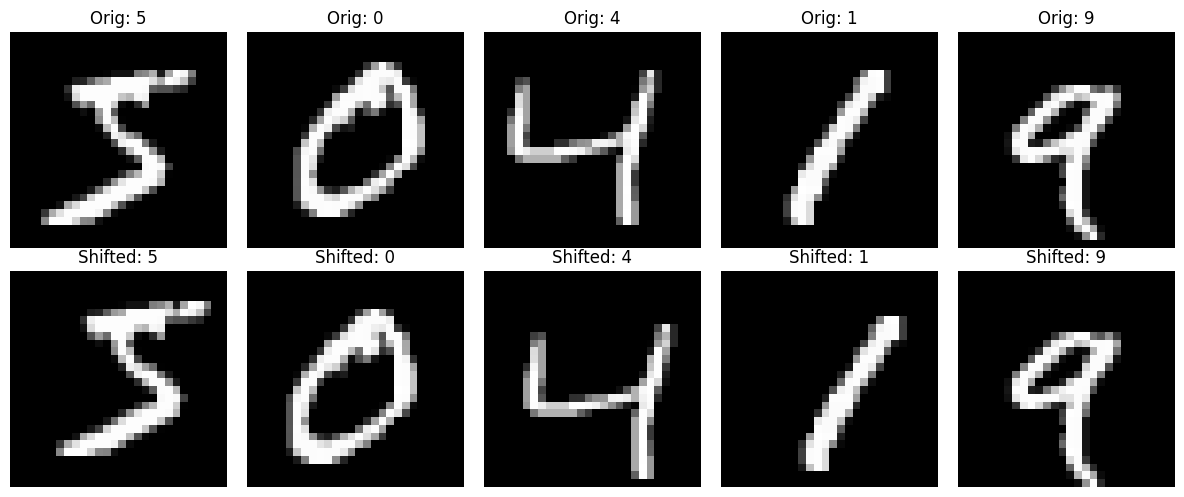

In [6]:
# Visualize original and augmented MNIST images

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i in range(5):

    # Original
    image, label = mnist_train[i]
    axes[0, i].imshow(image.squeeze(), cmap='gray')
    axes[0, i].set_title(f"Orig: {label}")
    axes[0, i].axis('off')

    # Augmented
    aug_image, aug_label = mnist_train_aug[i]
    axes[1, i].imshow(aug_image.squeeze(), cmap='gray')
    axes[1, i].set_title(f"Shifted: {aug_label}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
import snntorch as snn
from snntorch import spikegen

# Simulation parameters
num_steps = 25  # number of time steps

# Get one batch from MNIST loader
data_iter = iter(mnist_loader)
images, labels = next(data_iter)

# Move to device
images = images.to(device)
labels = labels.to(device)

# Flatten images: [batch, 1, 28, 28] -> [batch, 784]
images_flat = images.view(images.size(0), -1)

# -----------------------------
# Latency Encoding
# -----------------------------
spike_data = spikegen.latency(
    images_flat,
    num_steps=num_steps,
    normalize=True,
    linear=True
)

print("Original image shape:", images.shape)
print("Flattened shape:", images_flat.shape)
print("Spike data shape:", spike_data.shape)

Original image shape: torch.Size([128, 1, 28, 28])
Flattened shape: torch.Size([128, 784])
Spike data shape: torch.Size([25, 128, 784])


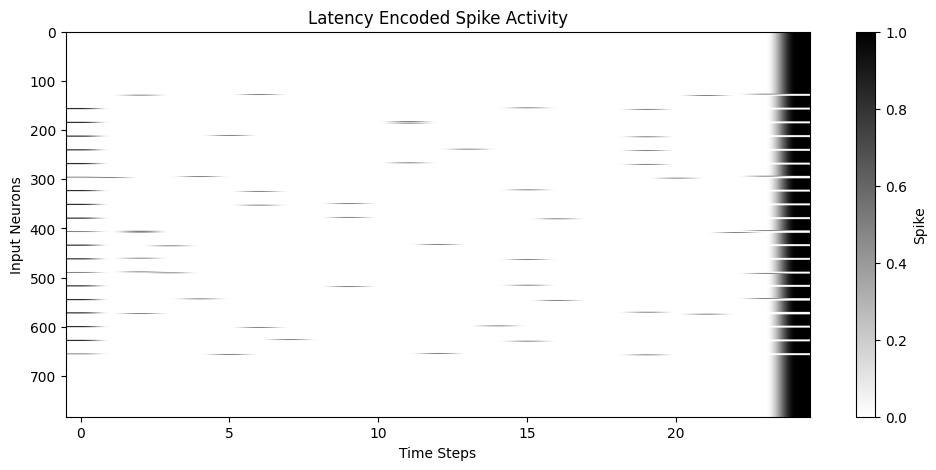

In [8]:
# Visualize spike activity for one sample

sample_idx = 0

spike_sample = spike_data[:, sample_idx, :].cpu()

plt.figure(figsize=(12,5))

plt.imshow(spike_sample.T, aspect='auto', cmap='binary')

plt.xlabel("Time Steps")
plt.ylabel("Input Neurons")
plt.title("Latency Encoded Spike Activity")

plt.colorbar(label="Spike")
plt.show()

In [9]:
import torch.nn as nn
import snntorch.functional as SF
from snntorch import surrogate

# -----------------------------
# Network Parameters
# -----------------------------
num_inputs = 784
num_hidden = 256
num_outputs = 10

beta = 0.95

# Surrogate gradient
spike_grad = surrogate.fast_sigmoid()

# -----------------------------
# Define Network
# -----------------------------
class SNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):

        # Initialize hidden states
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        # Loop through time steps
        for step in range(x.size(0)):

            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec), torch.stack(mem2_rec)

# -----------------------------
# Initialize Model
# -----------------------------
net = SNN().to(device)

print(net)

SNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (lif2): Leaky()
)


In [10]:
# -----------------------------
# Forward Pass Test
# -----------------------------

# Use previously created spike_data
spk_out, mem_out = net(spike_data)

print("Spike Output Shape:", spk_out.shape)
print("Membrane Output Shape:", mem_out.shape)

Spike Output Shape: torch.Size([25, 128, 10])
Membrane Output Shape: torch.Size([25, 128, 10])


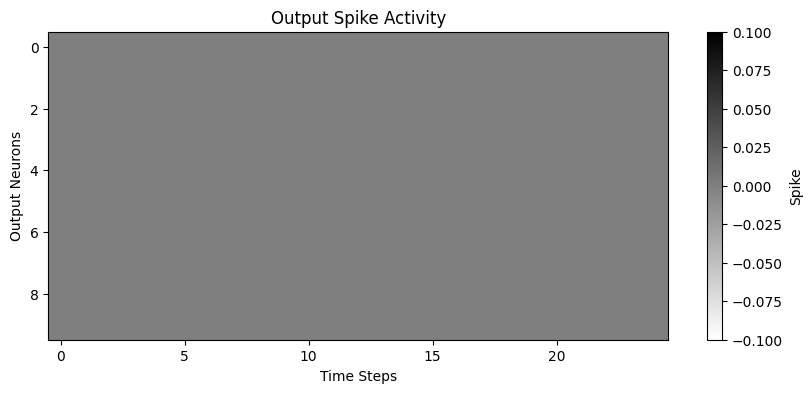

In [11]:
# -----------------------------
# Visualize Output Spikes
# -----------------------------

sample_idx = 0

output_spikes = spk_out[:, sample_idx, :].detach().cpu()

plt.figure(figsize=(10,4))

plt.imshow(output_spikes.T, aspect='auto', cmap='binary')

plt.xlabel("Time Steps")
plt.ylabel("Output Neurons")
plt.title("Output Spike Activity")

plt.colorbar(label="Spike")

plt.show()

In [12]:
import torch.optim as optim

# -----------------------------
# Loss Function
# -----------------------------
loss_fn = SF.ce_count_loss()

# -----------------------------
# Optimizer
# -----------------------------
optimizer = optim.Adam(net.parameters(), lr=1e-3)

print("Loss and optimizer initialized successfully!")

Loss and optimizer initialized successfully!


In [13]:
# -----------------------------
# Training Parameters
# -----------------------------
num_epochs = 10
num_steps = 25

# Store metrics
train_loss_hist = []
train_acc_hist = []

# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(num_epochs):

    net.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in mnist_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten images
        data = data.view(data.size(0), -1)

        # Latency encoding
        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Prediction from spike counts
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(mnist_loader)
    epoch_acc = 100 * correct / total

    train_loss_hist.append(epoch_loss)
    train_acc_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/10] Loss: 0.4757 Accuracy: 84.38%
Epoch [2/10] Loss: 0.2240 Accuracy: 93.44%
Epoch [3/10] Loss: 0.1774 Accuracy: 94.76%
Epoch [4/10] Loss: 0.1455 Accuracy: 95.70%
Epoch [5/10] Loss: 0.1212 Accuracy: 96.36%
Epoch [6/10] Loss: 0.1030 Accuracy: 96.98%
Epoch [7/10] Loss: 0.0911 Accuracy: 97.32%
Epoch [8/10] Loss: 0.0772 Accuracy: 97.71%
Epoch [9/10] Loss: 0.0716 Accuracy: 97.80%
Epoch [10/10] Loss: 0.0620 Accuracy: 98.14%


In [14]:
# -----------------------------
# Evaluation on Test Set
# -----------------------------

net.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in mnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency encoding
        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net(spike_data)

        # Prediction
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 97.31%


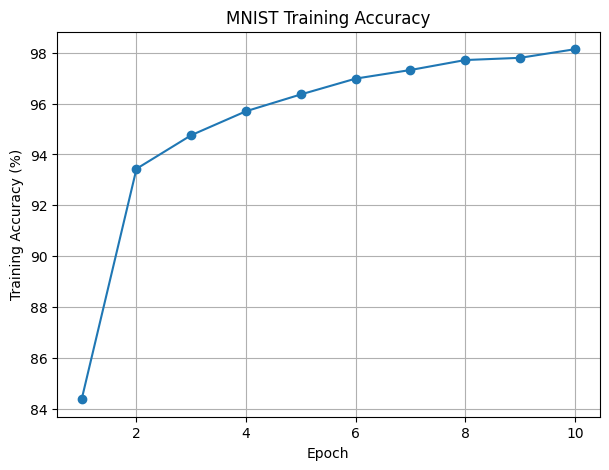

In [15]:
# -----------------------------
# Plot Accuracy Curve
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(range(1, num_epochs+1), train_acc_hist, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("MNIST Training Accuracy")

plt.grid(True)

plt.show()

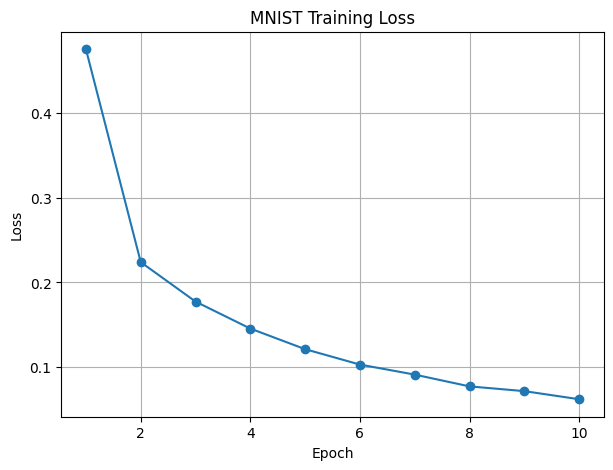

In [16]:
# -----------------------------
# Plot Loss Curve
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(range(1, num_epochs+1), train_loss_hist, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training Loss")

plt.grid(True)

plt.show()

In [17]:
# -----------------------------
# Create NEW Network
# -----------------------------
net_aug = SNN().to(device)

# Optimizer
optimizer_aug = optim.Adam(net_aug.parameters(), lr=1e-3)

# Training history
train_loss_aug_hist = []
train_acc_aug_hist = []

# -----------------------------
# Train on AUGMENTED MNIST
# -----------------------------
num_epochs = 10

for epoch in range(num_epochs):

    net_aug.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in mnist_aug_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency encoding
        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net_aug(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer_aug.zero_grad()
        loss.backward()
        optimizer_aug.step()

        total_loss += loss.item()

        # Accuracy
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(mnist_aug_loader)
    epoch_acc = 100 * correct / total

    train_loss_aug_hist.append(epoch_loss)
    train_acc_aug_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/10] Loss: 0.8723 Accuracy: 70.74%
Epoch [2/10] Loss: 0.3655 Accuracy: 88.67%
Epoch [3/10] Loss: 0.2672 Accuracy: 91.81%
Epoch [4/10] Loss: 0.2291 Accuracy: 92.92%
Epoch [5/10] Loss: 0.2015 Accuracy: 93.83%
Epoch [6/10] Loss: 0.1850 Accuracy: 94.34%
Epoch [7/10] Loss: 0.1729 Accuracy: 94.74%
Epoch [8/10] Loss: 0.1604 Accuracy: 95.11%
Epoch [9/10] Loss: 0.1548 Accuracy: 95.23%
Epoch [10/10] Loss: 0.1505 Accuracy: 95.38%


In [18]:
# -----------------------------
# Test Accuracy (Augmented Model)
# -----------------------------

net_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in mnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = data.view(data.size(0), -1)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        spk_out, mem_out = net_aug(spike_data)

        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

aug_test_acc = 100 * correct / total

print(f"Augmented MNIST Test Accuracy: {aug_test_acc:.2f}%")

Augmented MNIST Test Accuracy: 96.58%


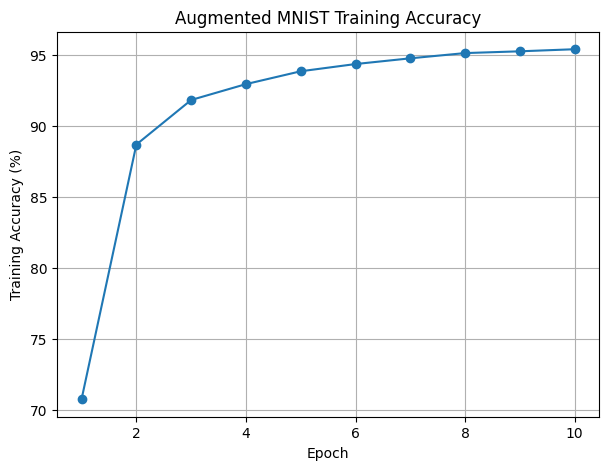

In [19]:
# -----------------------------
# Augmented MNIST Training Accuracy
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_acc_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Augmented MNIST Training Accuracy")

plt.grid(True)

plt.show()

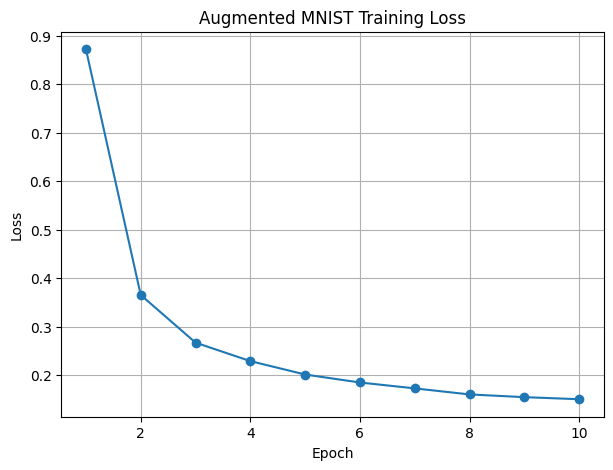

In [20]:
# -----------------------------
# Augmented MNIST Training Loss
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_loss_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmented MNIST Training Loss")

plt.grid(True)

plt.show()

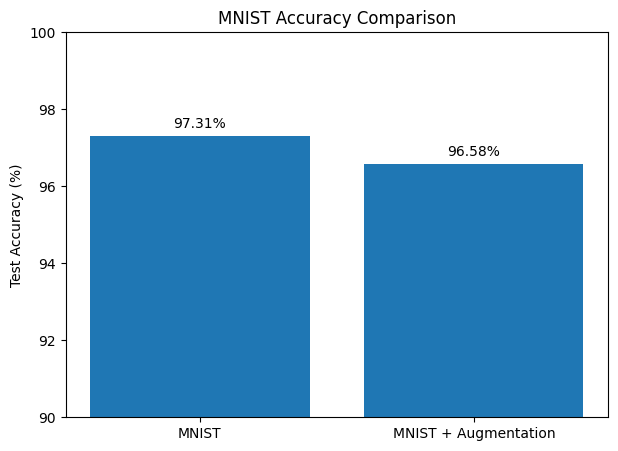

In [21]:
# -----------------------------
# Compare Test Accuracies
# -----------------------------

labels = ["MNIST", "MNIST + Augmentation"]
accuracies = [test_acc, aug_test_acc]

plt.figure(figsize=(7,5))

plt.bar(labels, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("MNIST Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(90, 100)

plt.show()

In [22]:
# -----------------------------
# NEW NETWORK FOR FASHION-MNIST
# -----------------------------
net_fmnist = SNN().to(device)

optimizer_fmnist = optim.Adam(
    net_fmnist.parameters(),
    lr=1e-3
)

# History
train_loss_fmnist_hist = []
train_acc_fmnist_hist = []

# -----------------------------
# Train on Fashion-MNIST
# -----------------------------
num_epochs = 10

for epoch in range(num_epochs):

    net_fmnist.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in fmnist_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency Encoding
        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net_fmnist(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer_fmnist.zero_grad()
        loss.backward()
        optimizer_fmnist.step()

        total_loss += loss.item()

        # Accuracy
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(fmnist_loader)
    epoch_acc = 100 * correct / total

    train_loss_fmnist_hist.append(epoch_loss)
    train_acc_fmnist_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/10] Loss: 0.6222 Accuracy: 77.98%
Epoch [2/10] Loss: 0.4122 Accuracy: 85.11%
Epoch [3/10] Loss: 0.3630 Accuracy: 86.97%
Epoch [4/10] Loss: 0.3413 Accuracy: 87.67%
Epoch [5/10] Loss: 0.3197 Accuracy: 88.36%
Epoch [6/10] Loss: 0.3068 Accuracy: 88.77%
Epoch [7/10] Loss: 0.2950 Accuracy: 89.15%
Epoch [8/10] Loss: 0.2834 Accuracy: 89.71%
Epoch [9/10] Loss: 0.2768 Accuracy: 89.90%
Epoch [10/10] Loss: 0.2601 Accuracy: 90.61%


In [23]:
# -----------------------------
# Test Accuracy on Fashion-MNIST
# -----------------------------

net_fmnist.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in fmnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = data.view(data.size(0), -1)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        spk_out, mem_out = net_fmnist(spike_data)

        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

fmnist_test_acc = 100 * correct / total

print(f"Fashion-MNIST Test Accuracy: {fmnist_test_acc:.2f}%")

Fashion-MNIST Test Accuracy: 88.00%


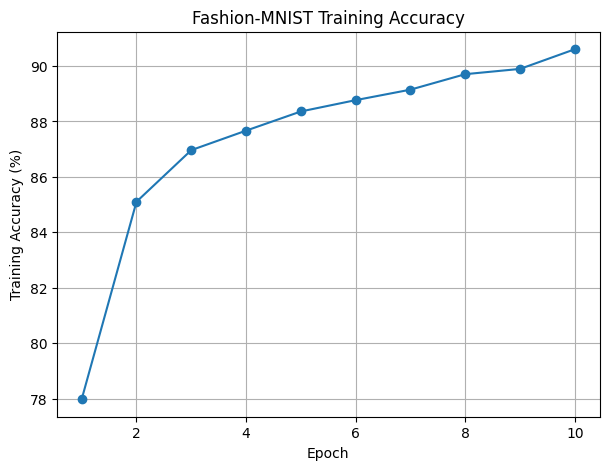

In [24]:
# -----------------------------
# Fashion-MNIST Accuracy Curve
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_acc_fmnist_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Fashion-MNIST Training Accuracy")

plt.grid(True)

plt.show()

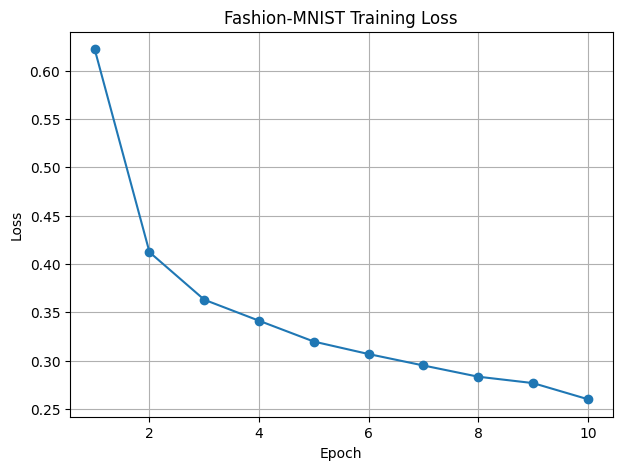

In [25]:
# -----------------------------
# Fashion-MNIST Loss Curve
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_loss_fmnist_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fashion-MNIST Training Loss")

plt.grid(True)

plt.show()

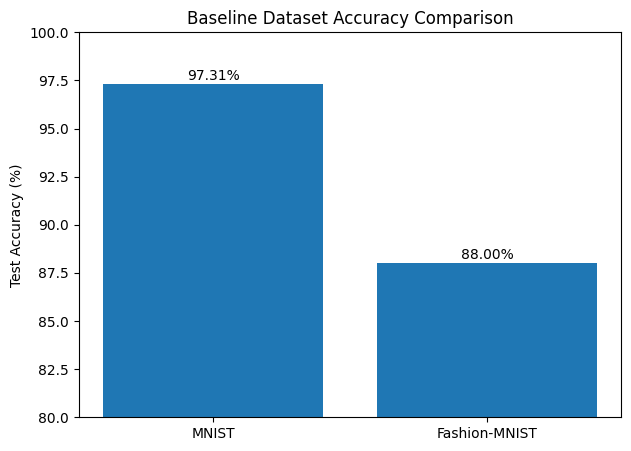

In [26]:
# -----------------------------
# Baseline Dataset Comparison
# -----------------------------

datasets_names = ["MNIST", "Fashion-MNIST"]
baseline_accuracies = [test_acc, fmnist_test_acc]

plt.figure(figsize=(7,5))

plt.bar(datasets_names, baseline_accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Baseline Dataset Accuracy Comparison")

for i, v in enumerate(baseline_accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(80, 100)

plt.show()

In [27]:
# -----------------------------
# NEW NETWORK FOR AUGMENTED F-MNIST
# -----------------------------
net_fmnist_aug = SNN().to(device)

optimizer_fmnist_aug = optim.Adam(
    net_fmnist_aug.parameters(),
    lr=1e-3
)

# History
train_loss_fmnist_aug_hist = []
train_acc_fmnist_aug_hist = []

# -----------------------------
# Train on Augmented Fashion-MNIST
# -----------------------------
num_epochs = 10

for epoch in range(num_epochs):

    net_fmnist_aug.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, targets in fmnist_aug_loader:

        data = data.to(device)
        targets = targets.to(device)

        # Flatten
        data = data.view(data.size(0), -1)

        # Latency encoding
        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        # Forward pass
        spk_out, mem_out = net_fmnist_aug(spike_data)

        # Loss
        loss = loss_fn(spk_out, targets)

        # Backprop
        optimizer_fmnist_aug.zero_grad()
        loss.backward()
        optimizer_fmnist_aug.step()

        total_loss += loss.item()

        # Accuracy
        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    epoch_loss = total_loss / len(fmnist_aug_loader)
    epoch_acc = 100 * correct / total

    train_loss_fmnist_aug_hist.append(epoch_loss)
    train_acc_fmnist_aug_hist.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/10] Loss: 0.8613 Accuracy: 67.97%
Epoch [2/10] Loss: 0.6378 Accuracy: 76.07%
Epoch [3/10] Loss: 0.5874 Accuracy: 78.00%
Epoch [4/10] Loss: 0.5596 Accuracy: 79.11%
Epoch [5/10] Loss: 0.5335 Accuracy: 80.11%
Epoch [6/10] Loss: 0.5205 Accuracy: 80.61%
Epoch [7/10] Loss: 0.5061 Accuracy: 81.16%
Epoch [8/10] Loss: 0.4975 Accuracy: 81.53%
Epoch [9/10] Loss: 0.4906 Accuracy: 81.81%
Epoch [10/10] Loss: 0.4807 Accuracy: 82.04%


In [28]:
# -----------------------------
# Test Accuracy
# Augmented Fashion-MNIST
# -----------------------------

net_fmnist_aug.eval()

correct = 0
total = 0

with torch.no_grad():

    for data, targets in fmnist_test_loader:

        data = data.to(device)
        targets = targets.to(device)

        data = data.view(data.size(0), -1)

        spike_data = spikegen.latency(
            data,
            num_steps=num_steps,
            normalize=True,
            linear=True
        )

        spk_out, mem_out = net_fmnist_aug(spike_data)

        spike_counts = spk_out.sum(dim=0)
        predicted = spike_counts.argmax(dim=1)

        correct += (predicted == targets).sum().item()
        total += targets.size(0)

fmnist_aug_test_acc = 100 * correct / total

print(f"Augmented Fashion-MNIST Test Accuracy: {fmnist_aug_test_acc:.2f}%")

Augmented Fashion-MNIST Test Accuracy: 83.87%


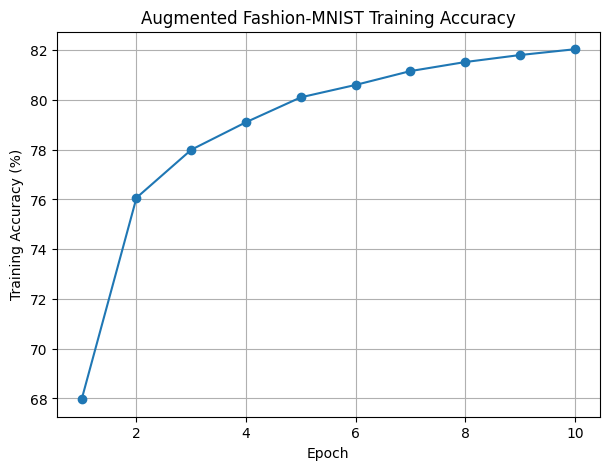

In [29]:
# -----------------------------
# Augmented Fashion-MNIST Accuracy
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_acc_fmnist_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Augmented Fashion-MNIST Training Accuracy")

plt.grid(True)

plt.show()

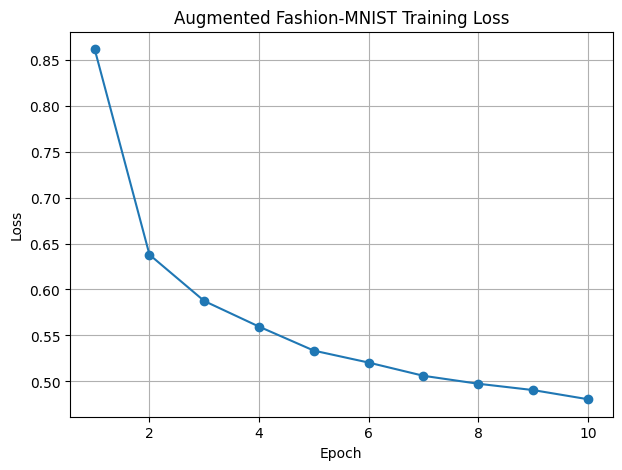

In [30]:
# -----------------------------
# Augmented Fashion-MNIST Loss
# -----------------------------

plt.figure(figsize=(7,5))

plt.plot(
    range(1, num_epochs+1),
    train_loss_fmnist_aug_hist,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmented Fashion-MNIST Training Loss")

plt.grid(True)

plt.show()

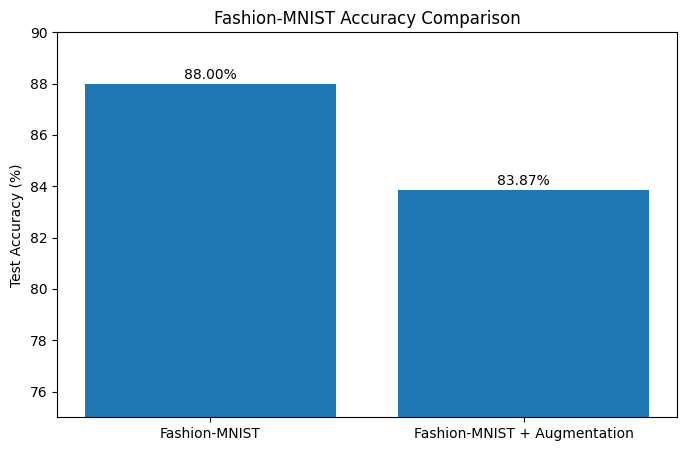

In [31]:
# -----------------------------
# Fashion-MNIST Comparison
# -----------------------------

labels = [
    "Fashion-MNIST",
    "Fashion-MNIST + Augmentation"
]

accuracies = [
    fmnist_test_acc,
    fmnist_aug_test_acc
]

plt.figure(figsize=(8,5))

plt.bar(labels, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Fashion-MNIST Accuracy Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(75, 90)

plt.show()

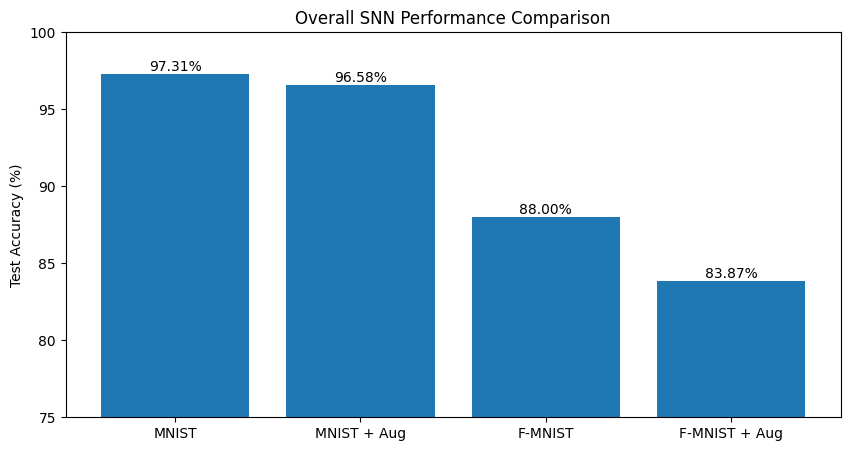

In [32]:
# -----------------------------
# Final Overall Comparison
# -----------------------------

experiment_names = [
    "MNIST",
    "MNIST + Aug",
    "F-MNIST",
    "F-MNIST + Aug"
]

final_accuracies = [
    test_acc,
    aug_test_acc,
    fmnist_test_acc,
    fmnist_aug_test_acc
]

plt.figure(figsize=(10,5))

plt.bar(experiment_names, final_accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Overall SNN Performance Comparison")

for i, v in enumerate(final_accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.ylim(75, 100)

plt.show()

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# -----------------------------
# Confusion Matrix Function
# -----------------------------
def plot_confusion_matrix(
    model,
    loader,
    class_labels,
    title
):

    all_preds = []
    all_targets = []

    model.eval()

    with torch.no_grad():

        for data, targets in loader:

            data = data.to(device)
            targets = targets.to(device)

            # Flatten
            data = data.view(data.size(0), -1)

            # Latency Encoding
            spike_data = spikegen.latency(
                data,
                num_steps=num_steps,
                normalize=True,
                linear=True
            )

            # Forward Pass
            spk_out, mem_out = model(spike_data)

            spike_counts = spk_out.sum(dim=0)
            predicted = spike_counts.argmax(dim=1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # Create confusion matrix
    cm = confusion_matrix(all_targets, all_preds)

    # Plot
    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.show()

In [34]:
# MNIST labels
mnist_labels = [
    "0","1","2","3","4",
    "5","6","7","8","9"
]

# Fashion-MNIST labels
fashion_labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

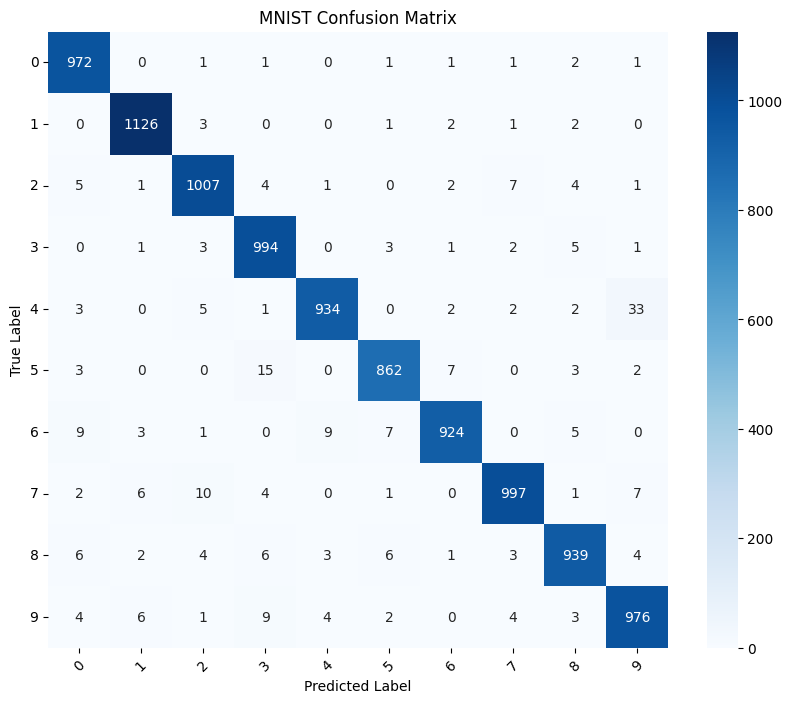

In [35]:
plot_confusion_matrix(
    net,
    mnist_test_loader,
    mnist_labels,
    "MNIST Confusion Matrix"
)

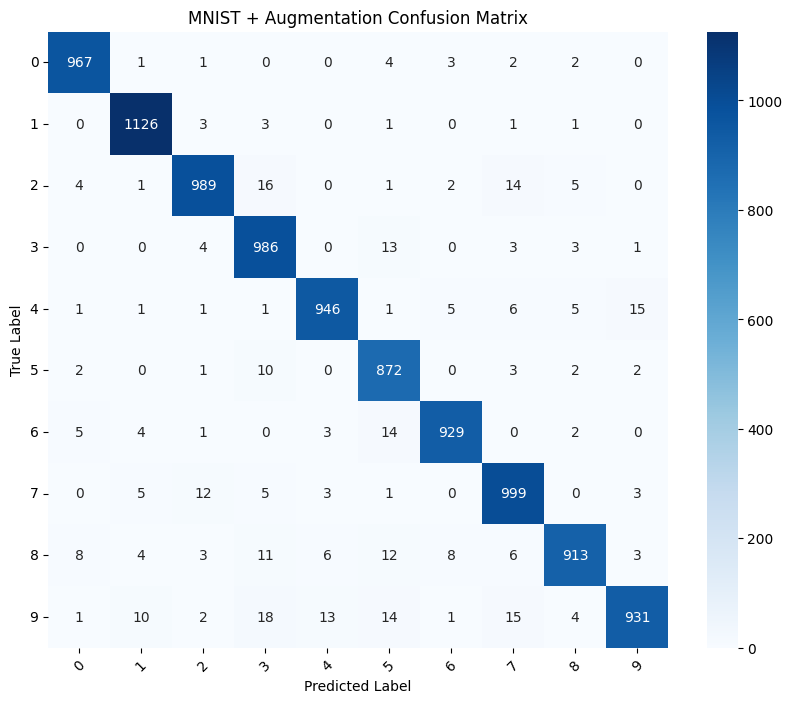

In [36]:
plot_confusion_matrix(
    net_aug,
    mnist_test_loader,
    mnist_labels,
    "MNIST + Augmentation Confusion Matrix"
)

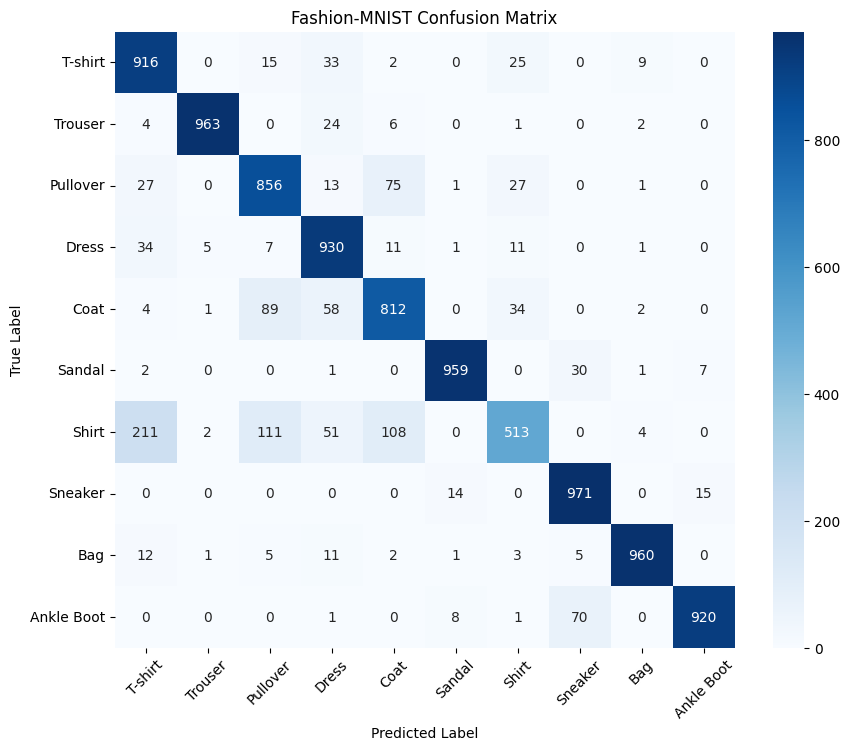

In [37]:
plot_confusion_matrix(
    net_fmnist,
    fmnist_test_loader,
    fashion_labels,
    "Fashion-MNIST Confusion Matrix"
)

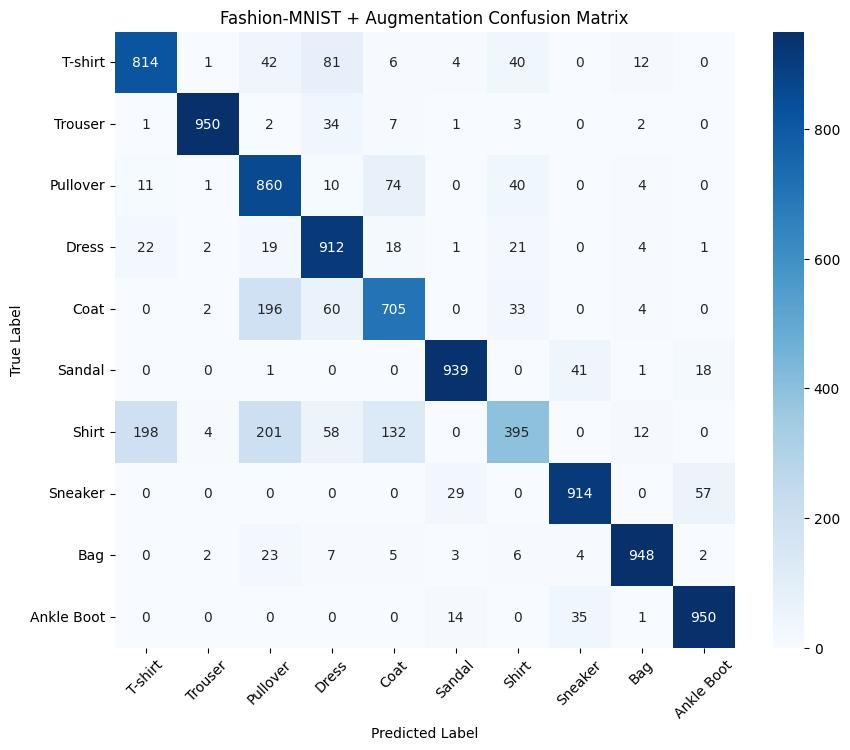

In [38]:
plot_confusion_matrix(
    net_fmnist_aug,
    fmnist_test_loader,
    fashion_labels,
    "Fashion-MNIST + Augmentation Confusion Matrix"
)

In [39]:
import pandas as pd

# -----------------------------
# Final Results Table
# -----------------------------
results_df = pd.DataFrame({
    "Experiment": [
        "MNIST",
        "MNIST + Augmentation",
        "Fashion-MNIST",
        "Fashion-MNIST + Augmentation"
    ],
    "Test Accuracy (%)": [
        round(test_acc, 2),
        round(aug_test_acc, 2),
        round(fmnist_test_acc, 2),
        round(fmnist_aug_test_acc, 2)
    ]
})

print(results_df)

                     Experiment  Test Accuracy (%)
0                         MNIST              97.31
1          MNIST + Augmentation              96.58
2                 Fashion-MNIST              88.00
3  Fashion-MNIST + Augmentation              83.87


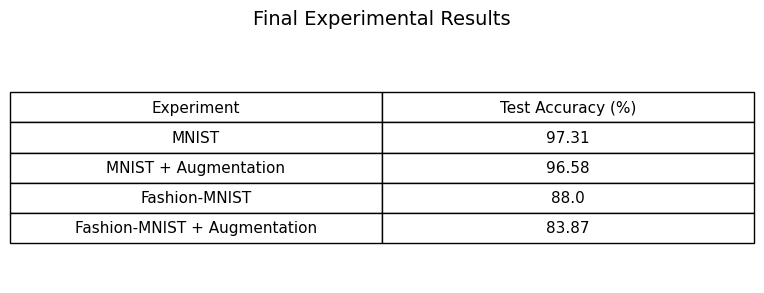

In [40]:
# -----------------------------
# Visual Results Table
# -----------------------------

import pandas as pd

# Create dataframe
results_df = pd.DataFrame({
    "Experiment": [
        "MNIST",
        "MNIST + Augmentation",
        "Fashion-MNIST",
        "Fashion-MNIST + Augmentation"
    ],
    "Test Accuracy (%)": [
        round(test_acc, 2),
        round(aug_test_acc, 2),
        round(fmnist_test_acc, 2),
        round(fmnist_aug_test_acc, 2)
    ]
})

# -----------------------------
# Plot Styled Table
# -----------------------------
fig, ax = plt.subplots(figsize=(8,3))

ax.axis('off')

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title(
    "Final Experimental Results",
    fontsize=14,
    pad=20
)

plt.show()